# Rossmann Store Sales Forecast

Predicts daily `Sales` for a Rossmann drug store from store metadata, promotions
and calendar features. This notebook does the full job: load data, engineer
features, train an XGBoost regressor, evaluate it honestly on a held-out
validation split, and save the trained model + preprocessors as `.pkl` files
so `app.py` can load them directly (no separate training script — this
notebook *is* the pipeline).

**Dataset**: [Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales/data) (Kaggle competition) — ~1.02M daily records, 1,115 stores, Jan 2013–Jul 2015.

In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Download the data

Requires a Kaggle account + API token (`~/.kaggle/kaggle.json`) and joining the
[competition](https://www.kaggle.com/c/rossmann-store-sales/rules). Skip this
cell if you already have `data/raw/rossmann-store-sales/{train,store,test}.csv`.

In [2]:
RAW_DIR = os.path.join("data", "raw")

def download_data(raw_dir=RAW_DIR):
    import opendatasets as od
    os.makedirs(raw_dir, exist_ok=True)
    od.download("https://www.kaggle.com/c/rossmann-store-sales/data", data_dir=raw_dir)

# download_data()  # uncomment on first run

In [3]:
train_df = pd.read_csv(os.path.join(RAW_DIR, "rossmann-store-sales", "train.csv"), low_memory=False)
test_df = pd.read_csv(os.path.join(RAW_DIR, "rossmann-store-sales", "test.csv"), low_memory=False)
store_df = pd.read_csv(os.path.join(RAW_DIR, "rossmann-store-sales", "store.csv"))

train_df.shape, test_df.shape, store_df.shape

((2400, 9), (50, 8), (20, 10))

## 2. Merge store metadata onto train/test

In [4]:
merged_df = train_df.merge(store_df, how="left", on="Store")
merged_test_df = test_df.merge(store_df, how="left", on="Store")
merged_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,4,2015-01-01,7881.00,673,1,1,a,0,b,b,7313.238615,5.0,2008.0,1,27.0,2014.0,"Mar,Jun,Sept,Dec"
1,1,5,2015-01-02,5887.78,721,1,0,0,0,b,b,7313.238615,5.0,2008.0,1,27.0,2014.0,"Mar,Jun,Sept,Dec"
2,1,6,2015-01-03,6554.49,602,1,0,0,0,b,b,7313.238615,5.0,2008.0,1,27.0,2014.0,"Mar,Jun,Sept,Dec"
3,1,7,2015-01-04,0.00,0,0,0,0,1,b,b,7313.238615,5.0,2008.0,1,27.0,2014.0,"Mar,Jun,Sept,Dec"
4,1,1,2015-01-05,6690.38,713,1,0,0,0,b,b,7313.238615,5.0,2008.0,1,27.0,2014.0,"Mar,Jun,Sept,Dec"


## 3. Drop closed-store rows

A closed store (`Open == 0`) always has `Sales == 0` — that's not a pattern for
the model to learn, it's just noise, so these rows are dropped from training.

In [5]:
print("Before:", len(merged_df))
merged_df = merged_df[merged_df.Open == 1].copy()
print("After: ", len(merged_df))

Before: 2400
After:  2199


## 4. Quick EDA

A couple of sanity-check plots — enough to justify the features chosen below,
not a full exploration (that would be a separate notebook).

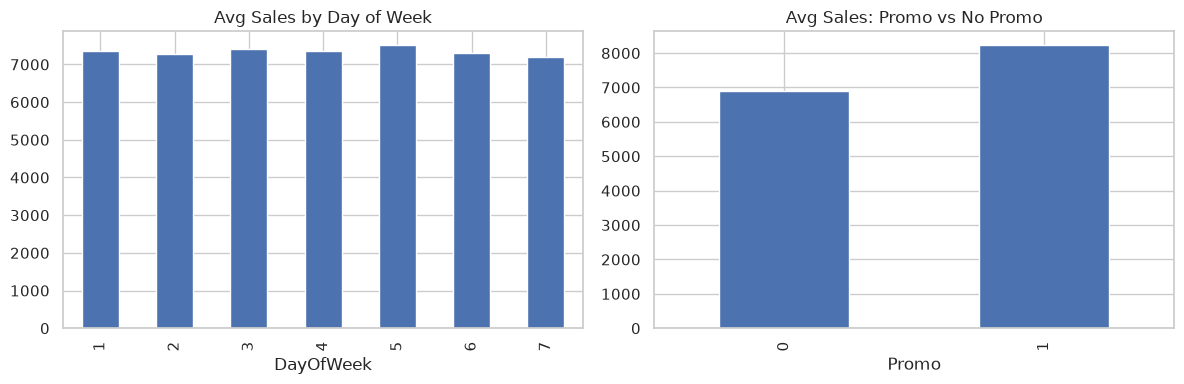

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
merged_df.groupby("DayOfWeek")["Sales"].mean().plot(kind="bar", ax=axes[0], title="Avg Sales by Day of Week")
merged_df.groupby("Promo")["Sales"].mean().plot(kind="bar", ax=axes[1], title="Avg Sales: Promo vs No Promo")
plt.tight_layout()
plt.show()

## 5. Feature engineering

Three engineered features, each a small, named function so they're easy to
test and explain individually:

- `CompetitionOpen` — months since the nearest competitor opened
- `Promo2Open` — months since the store's recurring "Promo2" campaign started
- `IsPromoMonth` — whether the current month is inside that store's active promo interval (e.g. `"Jan,Apr,Jul,Oct"`)

In [7]:
MONTH_MAP = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sept",10:"Oct",11:"Nov",12:"Dec"}

def split_date(df):
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df.Date.dt.year
    df["Month"] = df.Date.dt.month
    df["Day"] = df.Date.dt.day
    df["WeekOfYear"] = df.Date.dt.isocalendar().week.astype(int)

def add_competition_open_months(df):
    df["CompetitionOpen"] = 12 * (df.Year - df.CompetitionOpenSinceYear) + (df.Month - df.CompetitionOpenSinceMonth)
    df["CompetitionOpen"] = df["CompetitionOpen"].map(lambda x: 0 if x < 0 else x).fillna(0)

def add_promo2_open_months(df):
    df["Promo2Open"] = 12 * (df.Year - df.Promo2SinceYear) + (df.WeekOfYear - df.Promo2SinceWeek) * 7 / 30.5
    df["Promo2Open"] = df["Promo2Open"].map(lambda x: 0 if x < 0 else x).fillna(0) * df["Promo2"]

def add_is_promo_month(df):
    df["PromoInterval"] = df["PromoInterval"].fillna("")
    df["monthStr"] = df.Month.map(MONTH_MAP)
    df["IsPromoMonth"] = 0
    for interval in df.PromoInterval.unique():
        if interval == "":
            continue
        for month in interval.split(","):
            df.loc[(df.monthStr == month) & (df.PromoInterval == interval), "IsPromoMonth"] = 1

def engineer_features(df):
    split_date(df)
    add_competition_open_months(df)
    add_promo2_open_months(df)
    add_is_promo_month(df)
    return df

engineer_features(merged_df)
engineer_features(merged_test_df)
merged_df[["Date", "CompetitionOpen", "Promo2Open", "IsPromoMonth"]].sample(5, random_state=1)

,Date,CompetitionOpen,Promo2Open,IsPromoMonth
1398,2015-03-20,61.0,21.475410,1
1806,2015-01-07,3.0,0.524590,0
361,2015-01-02,154.0,0.000000,0
1594,2015-02-04,152.0,17.803279,0
2136,2015-04-07,121.0,51.967213,0


In [8]:
INPUT_COLS = [
    "Store", "DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday",
    "StoreType", "Assortment", "CompetitionDistance", "CompetitionOpen",
    "Day", "Month", "Year", "WeekOfYear", "Promo2", "Promo2Open", "IsPromoMonth",
]
TARGET_COL = "Sales"
NUMERIC_COLS = [
    "Store", "Promo", "SchoolHoliday", "CompetitionDistance", "CompetitionOpen",
    "Promo2", "Promo2Open", "IsPromoMonth", "Day", "Month", "Year", "WeekOfYear",
]
CATEGORICAL_COLS = ["DayOfWeek", "StateHoliday", "StoreType", "Assortment"]

inputs = merged_df[INPUT_COLS].copy()
targets = merged_df[TARGET_COL].copy()
test_inputs = merged_test_df[INPUT_COLS].copy()
inputs.shape, targets.shape

((2199, 16), (2199,))

## 6. Train / validation split

80/20 — the model never sees the validation rows during training, so
metrics on it are an honest estimate of how it'll do on new data.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    inputs, targets, test_size=0.2, random_state=RANDOM_STATE
)
len(X_train), len(X_val)

(1759, 440)

## 7. Preprocessing

`MinMaxScaler` on numeric columns, `OneHotEncoder` on categoricals — both fit
on the **training split only**, so nothing from validation leaks into their
statistics. Missing `CompetitionDistance` is filled with the training set's
max distance (i.e. "no known competitor" ≈ "very far away").

In [10]:
def fit_preprocessors(df):
    scaler = MinMaxScaler().fit(df[NUMERIC_COLS])
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(df[CATEGORICAL_COLS])
    return scaler, encoder

def transform(df, scaler, encoder):
    df = df.copy()
    max_distance = df["CompetitionDistance"].max()
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(max_distance)
    df[NUMERIC_COLS] = scaler.transform(df[NUMERIC_COLS])
    encoded_cols = list(encoder.get_feature_names_out(CATEGORICAL_COLS))
    df[encoded_cols] = encoder.transform(df[CATEGORICAL_COLS])
    return df[NUMERIC_COLS + encoded_cols]

scaler, encoder = fit_preprocessors(X_train)
X_train_enc = transform(X_train, scaler, encoder)
X_val_enc = transform(X_val, scaler, encoder)
X_train_enc.shape

(1759, 28)

## 8. Train XGBoost

Standard, lightly-tuned settings — a reasonable starting point, not an
aggressive hyperparameter search.

In [11]:
model = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1,
)
model.fit(X_train_enc, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 9. Evaluate on the held-out validation set

This is the number that matters — not training-set error, which just shows
how well the model memorized data it already saw.

In [12]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

train_preds = model.predict(X_train_enc)
val_preds = model.predict(X_val_enc)

print(f"Train RMSE:      {rmse(y_train, train_preds):.2f}")
print(f"Validation RMSE: {rmse(y_val, val_preds):.2f}")
print(f"Validation MAE:  {mean_absolute_error(y_val, val_preds):.2f}")
print(f"Validation R^2:  {r2_score(y_val, val_preds):.3f}")

Train RMSE:      110.02
Validation RMSE: 466.99
Validation MAE:  372.70
Validation R^2:  0.929


## 10. Feature importance

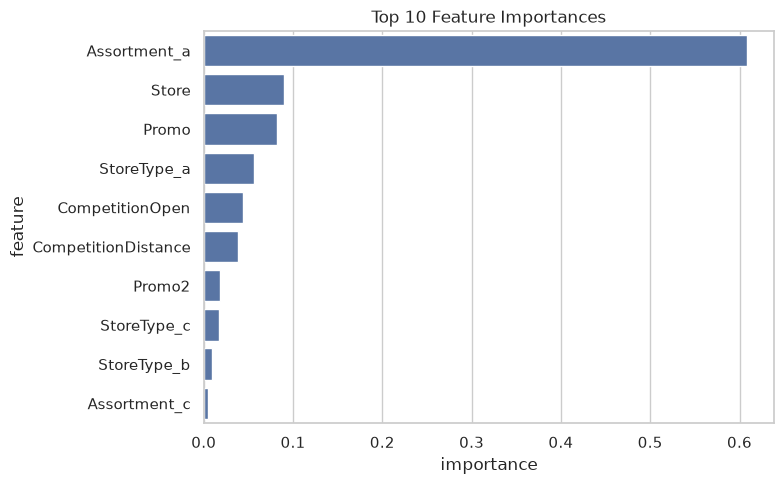

,feature,importance
25,Assortment_a,0.608217
0,Store,0.089756
1,Promo,0.082475
21,StoreType_a,0.056186
4,CompetitionOpen,0.044391
3,CompetitionDistance,0.038039
5,Promo2,0.018473
23,StoreType_c,0.017626
22,StoreType_b,0.008871
27,Assortment_c,0.004834


In [13]:
importance_df = pd.DataFrame({
    "feature": X_train_enc.columns,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

importance_df.head(10)

## 11. Save the model + preprocessors

Saved as plain `.pkl` files at the repo root so `app.py` can load them
directly with no extra path logic.

In [14]:
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("Saved xgb_model.pkl, scaler.pkl, encoder.pkl")

Saved xgb_model.pkl, scaler.pkl, encoder.pkl


## 12. (Optional) Kaggle-format predictions on the test set

In [15]:
test_inputs_enc = transform(test_inputs, scaler, encoder)
test_preds = pd.Series(model.predict(test_inputs_enc), index=test_inputs.index)
test_preds[merged_test_df["Open"] == 0] = 0

submission = pd.DataFrame({"Id": merged_test_df["Id"], "Sales": test_preds.values})
submission.to_csv("submission.csv", index=False)
submission.head()

,Id,Sales
0,1,6355.669434
1,2,5887.880859
2,3,7585.890137
3,4,10937.247070
4,5,0.000000
